RANDOM FOREST

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

Load tập train test đã lưu

In [2]:
X_train = joblib.load(
    "../processed/X_train.pkl"
)

X_test = joblib.load(
    "../processed/X_test.pkl"
)

y_train = joblib.load(
    "../processed/y_train.pkl"
)

y_test = joblib.load(
    "../processed/y_test.pkl"
)

Train model

In [4]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [5]:
rf_pred = rf.predict(X_test)

Accuracy

In [6]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Accuracy:", rf_accuracy)

Accuracy: 0.7934705464868701


Classification report

In [7]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1036
           1       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Confusion matrix

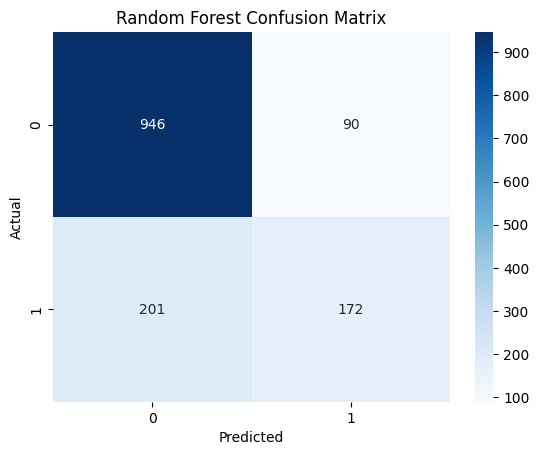

In [8]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Features improtance

In [9]:
importance = rf.feature_importances_

Tạo DataFrame

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

In [11]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [12]:
feature_importance.head(10)

,Feature,Importance
3,TotalCharges,0.196719
1,tenure,0.170752
2,MonthlyCharges,0.169223
28,PaymentMethod_Electronic check,0.036007
10,InternetService_Fiber optic,0.035989
25,Contract_Two year,0.031140
13,OnlineSecurity_Yes,0.028100
4,gender_Male,0.028045
26,PaperlessBilling_Yes,0.025510
5,Partner_Yes,0.023770


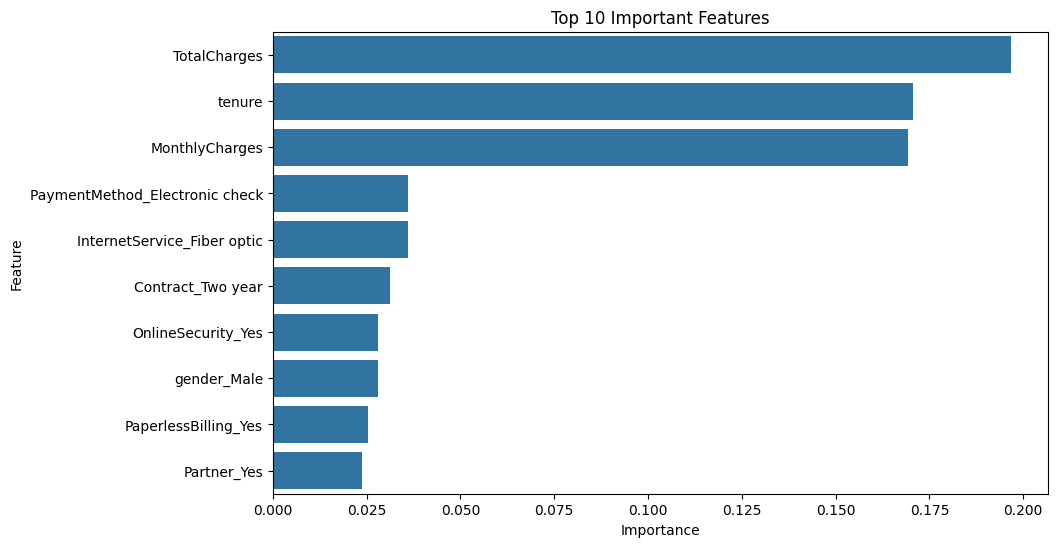

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

Lưu model

In [14]:
joblib.dump(
    rf,
    "../models/random_forest.pkl"
)

['../models/random_forest.pkl']

So sánh Logistic_regression với Random forest

In [16]:
log_model = joblib.load(
    "../models/logistic_regression_model.pkl"
)

In [17]:
log_pred = log_model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

log_accuracy = accuracy_score(
    y_test,
    log_pred
)

print(log_accuracy)

0.8211497515968772


In [19]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821150
1,Random Forest,0.793471


XGBOOST

In [20]:
from xgboost import XGBClassifier

In [21]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

In [22]:
xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [23]:
xgb_pred = xgb.predict(X_test)

In [24]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print(xgb_accuracy)

0.8076650106458482


In [25]:
print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1036
           1       0.66      0.56      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



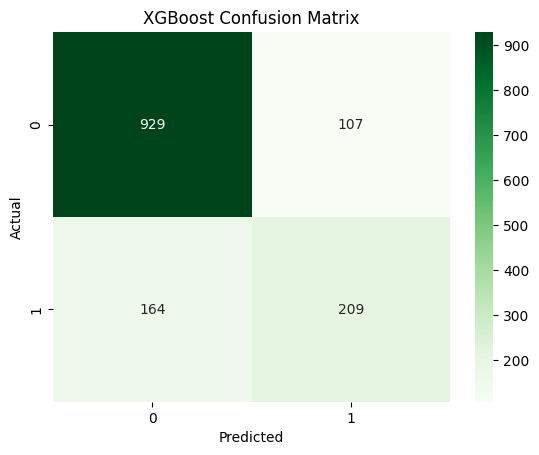

In [26]:
cm = confusion_matrix(
    y_test,
    xgb_pred
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [27]:
from sklearn.metrics import roc_auc_score

xgb_auc = roc_auc_score(
    y_test,
    xgb_pred
)

print(xgb_auc)

0.7285199312679206


In [28]:
joblib.dump(
    xgb,
    "../models/xgboost.pkl"
)

['../models/xgboost.pkl']

In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        log_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.821150
1,Random Forest,0.793471
2,XGBoost,0.807665


In [31]:
importance = xgb.feature_importances_

In [32]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
})

In [33]:
xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

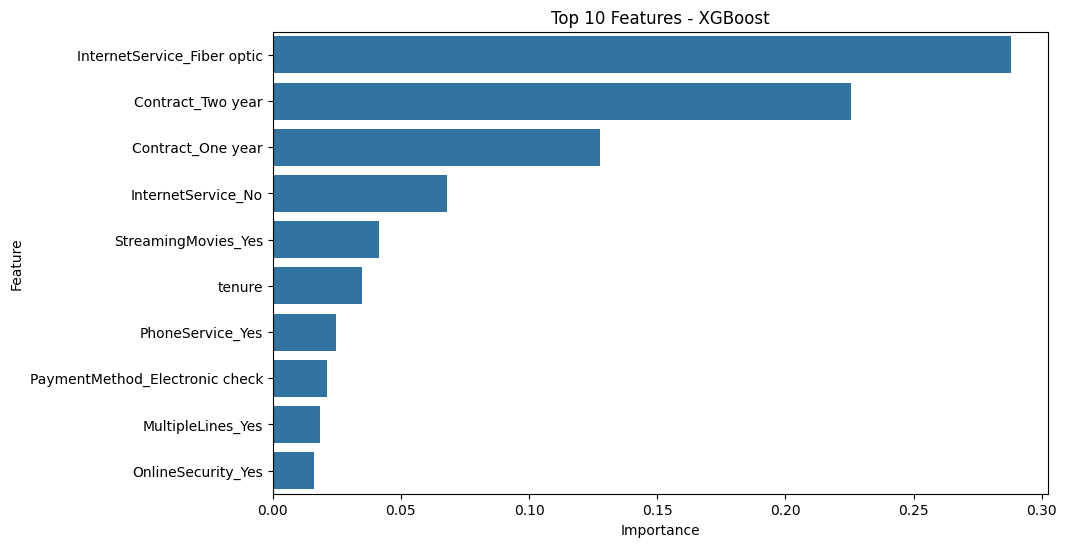

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=xgb_importance.head(10)
)

plt.title("Top 10 Features - XGBoost")

plt.show()